**Experiment No : 04**

**Aim :**Learn use of maplotlib library as visualisation tool in data science pipeline to create contour plots, histograms and box plots.

**Performance :**
[Students need to execute each and every cell in this section and note the output of the same. Once done they have to answer Questions mentioned in review section]

Density and Contour plots
Sometimes it is useful to display three-dimensional data in two dimensions using contours or color-coded regions.

There are three Matplotlib functions that can be helpful for this task: plt.contour for contour plots, plt.contourf for filled contour plots, and plt.imshow for showing images.

We will see examples of this type of plot in section below

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-white')
import numpy as np

In [ ]:
# A 3D function to plot

def f(x, y):
    return np.sin(x) ** 10 + np.cos(10 + y * x) * np.cos(x)

A contour plot can be created with the plt.contour function. It takes three arguments: a grid of x values, a grid of y values, and a grid of z values.

The x and y values represent positions on the plot, and the z values will be represented by the contour levels.

Perhaps the most straightforward way to prepare such data is to use the np.meshgrid function, which builds two-dimensional grids from one-dimensional arrays:

In [ ]:
# x is set of 50 values between 0 and 5
# x is set of 40 values between 0 and 5

x = np.linspace(0, 5, 50)
y = np.linspace(0, 5, 40)

X, Y = np.meshgrid(x, y)
Z = f(X, Y)

Now let's look at this with a standard line-only contour plot:

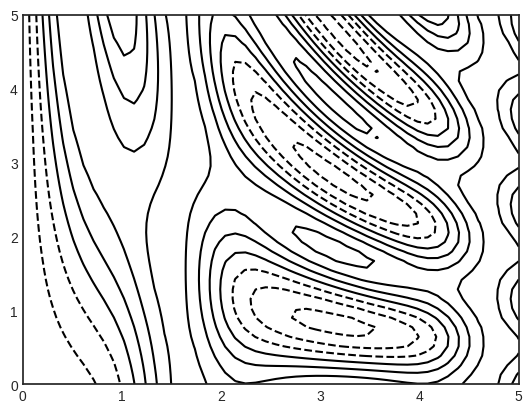

In [ ]:
plt.contour(X, Y, Z, colors='black');

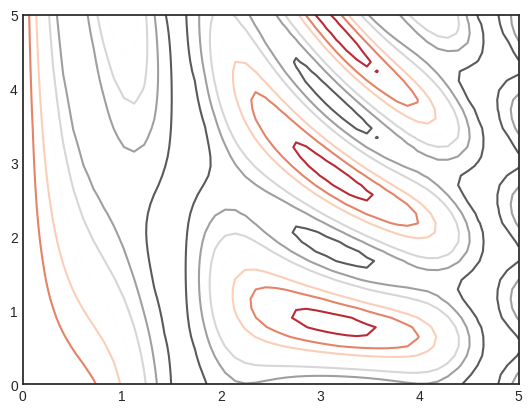

In [ ]:
plt.contour(X, Y, Z, cmap='RdGy');

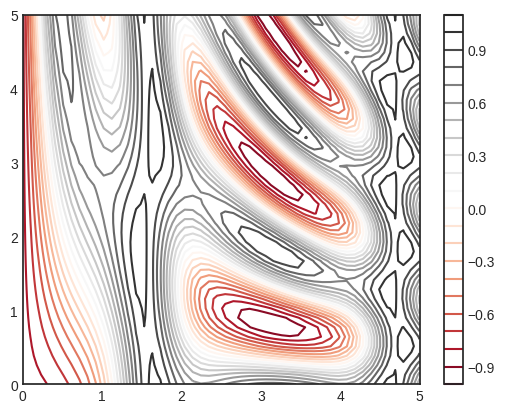

In [ ]:
plt.contour(X, Y, Z, 20, cmap='RdGy');
plt.colorbar();

**Q1** **Explain what are the changes you observe in contour plots above 3 code cells ?**
Let's break down the changes you observe in the three contour plots:

First plot (plt.contour(X, Y, Z, colors='black');): This plot shows the basic contour lines. By default, plt.contour creates a set number of contour lines (usually 8) to represent the different Z values. The colors='black' argument explicitly sets all these contour lines to be black, making it a monochromatic plot.

Second plot (plt.contour(X, Y, Z, cmap='RdGy');): In this plot, the cmap='RdGy' argument is introduced. This tells Matplotlib to use the 'Red-Gray' colormap to color the contour lines. Instead of a single color, the lines are now colored based on their Z values, with varying shades of red and gray, making it easier to distinguish different value ranges, though the specific Z values are not explicitly shown.

Third plot (plt.contour(X, Y, Z, 20, cmap='RdGy'); plt.colorbar();): This plot makes two key changes:

The argument 20 is added, which specifies that there should be 20 contour levels instead of the default. This results in a much finer and more detailed representation of the Z values, showing more variations in the data.
plt.colorbar() is called, which adds a color bar next to the plot. This color bar provides a visual legend, mapping the colors used in the contour lines to the actual Z values they represent. This makes it possible to quantitatively interpret the different colored regions of the plot.

Q2** **bold text**What is size of X, Y and Z respectively ?**


In [ ]:
print(f"Shape of X: {X.shape}")
print(f"Shape of Y: {Y.shape}")
print(f"Shape of Z: {Z.shape}")

Shape of X: (40, 50)
Shape of Y: (40, 50)
Shape of Z: (40, 50)


**Q3** **How does colorbar() method help in contour plot.**
The plt.colorbar() method is crucial in a contour plot because it provides a visual legend that maps the colors used in the plot to the actual data values (Z values) they represent. Without a color bar, while different colors might indicate varying levels, it would be impossible to quantitatively interpret what those colors correspond to. The color bar allows you to quickly understand the range of values and how they are distributed across the plot, making the visualization much more informative and interpretable.



**Creating Smoother Contour Plots**
One potential issue with this plot is that it is a bit "splotchy." That is, the color steps are discrete rather than continuous, which is not always what is desired.

This could be remedied by setting the number of contours to a very high number, but this results in a rather inefficient plot: Matplotlib must render a new polygon for each step in the level. A better way to handle this is to use the plt.imshow() function, which interprets a two-dimensional grid of data as an image.

The following code shows how to perform this:

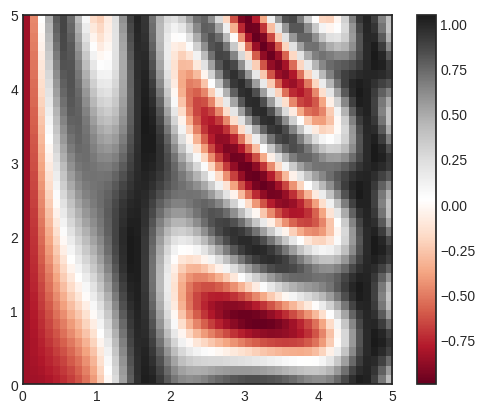

In [ ]:
plt.imshow(Z, extent=[0, 5, 0, 5], origin='lower',
           cmap='RdGy')
plt.colorbar()
plt.gca().set_aspect('equal');

Things to remember while using imshow():

plt.imshow() doesn't accept an x and y grid, so you must manually specify the extent [xmin, xmax, ymin, ymax] of the image on the plot.
plt.imshow() by default follows the standard image array definition where the origin is in the upper left, not in the lower left as in most contour plots. This must be changed when showing gridded data.
plt.imshow() will automatically adjust the axis aspect ratio to match the input data; this can be changed by setting, for example, plt.axis(aspect='image') to make x and y units match.

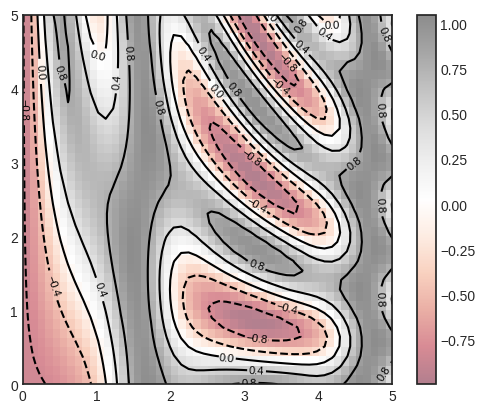

In [ ]:
contours = plt.contour(X, Y, Z, 5, colors='black')
plt.clabel(contours, inline=True, fontsize=8)

plt.imshow(Z, extent=[0, 5, 0, 5], origin='lower',
           cmap='RdGy', alpha=0.5)
plt.colorbar();

**Answer the following Questions**

**Q1** **What does alpha parameter do ?**
The alpha parameter in Matplotlib controls the transparency or opacity of a plot element. It takes a value between 0 (completely transparent) and 1 (completely opaque).

In the context of plt.imshow(..., alpha=0.5), it makes the image (in this case, the colored regions representing Z values) semi-transparent, allowing any elements plotted underneath or behind it to be partially visible. This is particularly useful when overlaying different plots, like the contour lines and the imshow image, to see both simultaneously.

**Q2** **What does clabel method does ?**  
The plt.clabel() method in Matplotlib is used to add labels to contour lines generated by plt.contour(). These labels typically display the data value that each contour line represents, making the plot more informative and easier to interpret.

In the notebook's example plt.clabel(contours, inline=True, fontsize=8):

contours: This is the output object from a plt.contour() call, containing the contour lines to be labeled.
inline=True: This argument causes the labels to be drawn inline, meaning they break the contour line where the label is placed, making them easier to read.
fontsize=8: This sets the font size of the labels to 8 points.

**Q3Recreate above code block after, changing parameter 4 in contour fuction to 5 from 3. Explain what change you see in the plot.**



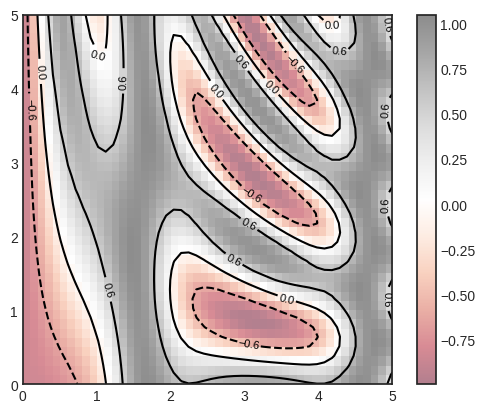

In [ ]:
contours = plt.contour(X, Y, Z, 3, colors='black') # Changed from 5 to 3
plt.clabel(contours, inline=True, fontsize=8)

plt.imshow(Z, extent=[0, 5, 0, 5], origin='lower',
           cmap='RdGy', alpha=0.5)
plt.colorbar();

Histogram, Binning Plots
A histogram is a graphical representation of a grouped frequency distribution with continuous classes. It is an area diagram and can be defined as a set of rectangles with bases along with the intervals between class boundaries and with areas proportional to frequencies in the corresponding classes. In such representations, all the rectangles are adjacent since the base covers the intervals between class boundaries. The heights of rectangles are proportional to corresponding frequencies of similar classes and for different classes, the heights will be proportional to corresponding frequency densities.

In other words, a histogram is a diagram involving rectangles whose area is proportional to the frequency of a variable and width is equal to the class interval.

The histogram graph is used under certain conditions. They are:

The data should be numerical.
A histogram is used to check the shape of the data distribution.
Used to check whether the process changes from one period to another.
Used to determine whether the output is different when it involves two or more processes.
Used to analyse whether the given process meets the customer requirements.

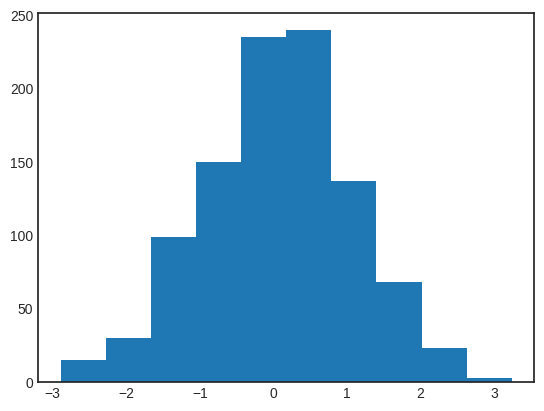

In [ ]:
# How to plot histogram
data = np.random.randn(1000)
plt.hist(data);


The hist() function has many options to tune both the calculation and the display; here's an example of a more customized histogram:

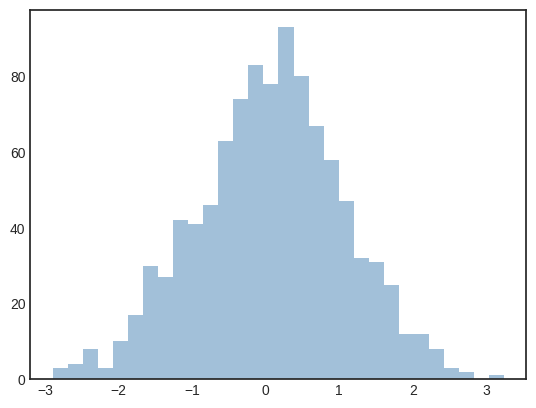

In [ ]:
plt.hist(data, bins=30, alpha=0.5, histtype='stepfilled', color='steelblue', edgecolor='none');

The plt.hist docstring has more information on other customization options available. I find this combination of histtype='stepfilled' along with some transparency alpha to be very useful when comparing histograms of several distributions:

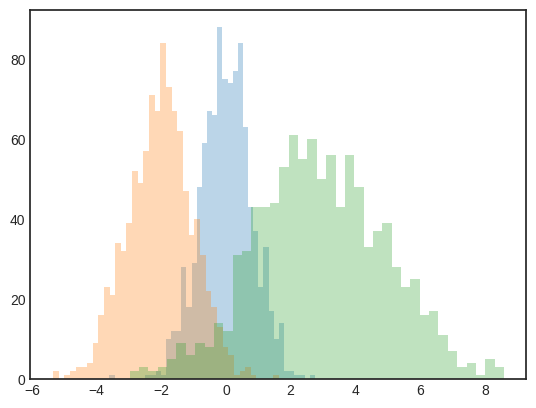

In [ ]:
x1 = np.random.normal(0, 0.8, 1000)
x2 = np.random.normal(-2, 1, 1000)
x3 = np.random.normal(3, 2, 1000)

kwargs = dict(histtype='stepfilled', alpha=0.3, bins=40)

plt.hist(x1, **kwargs)
plt.hist(x2, **kwargs)
plt.hist(x3, **kwargs);

If you would like to simply compute the histogram (that is, count the number of points in a given bin) and not display it, the np.histogram() function is available:

In [ ]:
#Only storing histogram bin frequencies without ploting it
counts, bin_edges = np.histogram(data, bins=5)
print(counts,bin_edges)

[ 45 249 475 205  26] [-2.88936389 -1.66364344 -0.437923    0.78779744  2.01351788  3.23923832]


plt.hist2d: Two-dimensional histogram
One straightforward way to plot a two-dimensional histogram is to use Matplotlib's plt.hist2d function:

In [ ]:
# Create 2 Variable normally distributed data sets with 10000
mean = [0, 0]
cov = [[1, 1], [1, 2]]
x, y = np.random.multivariate_normal(mean, cov, 10000).T

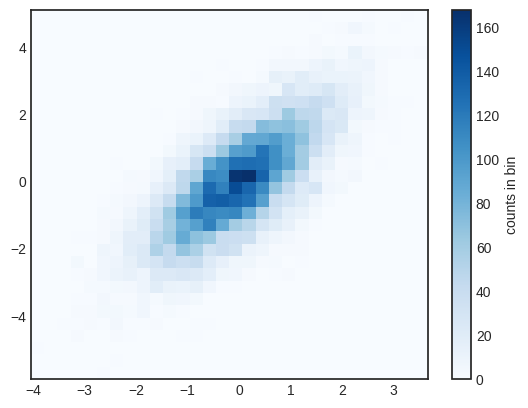

In [ ]:
#Using 2d Histogram plot
plt.hist2d(x, y, bins=30, cmap='Blues')
cb = plt.colorbar()
cb.set_label('counts in bin')


Just as with plt.hist, plt.hist2d has a number of extra options to fine-tune the plot and the binning, which are nicely outlined in the function docstring. Further, just as plt.hist has a counterpart in np.histogram, plt.hist2d has a counterpart in np.histogram2d, which can be used as follows:

In [ ]:
counts, xedges, yedges = np.histogram2d(x, y, bins=30)

plt.hexbin: Hexagonal binnings
The two-dimensional histogram creates a tesselation of squares across the axes. Another natural shape for such a tesselation is the regular hexagon. For this purpose, Matplotlib provides the plt.hexbin routine, which will represents a two-dimensional dataset binned within a grid of hexagons:

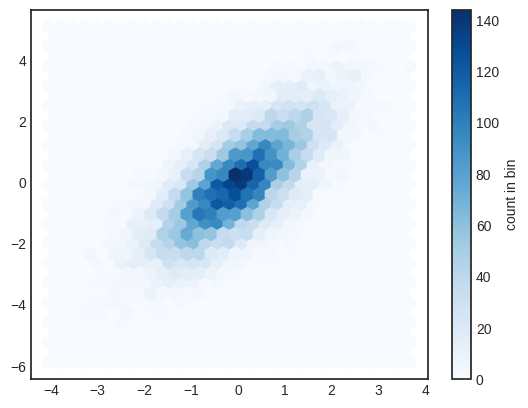

In [ ]:
plt.hexbin(x, y, gridsize=30, cmap='Blues')
cb = plt.colorbar(label='count in bin')

**Questions:**

**Q1What is role of bins parameter in histogram plot?**
The bins parameter in a histogram plot defines the number or the edges of the intervals (or 'bins') into which the data will be divided. Its role is crucial for how the distribution of the data is visualized:

Grouping Data: It groups data points into a series of intervals along the x-axis.
Frequency Counting: For each bin, the histogram counts how many data points fall within that interval.
Visual Representation: The height of each bar in the histogram then represents the frequency (or count) of data points in that specific bin.
Choosing the right number of bins is important:

Too few bins: Can hide important features of the data distribution, making it look overly smooth or simplistic.
Too many bins: Can make the histogram noisy, showing too much detail and potentially highlighting random fluctuations rather than the underlying pattern.

**Q2Create a set of 10000 uniform random samples and store it in variable named norm_data. Draw histograms of norm_data with following bin counts 5, 50, 500, 5000.**

In [ ]:
# Create 10000 uniform random samples
norm_data = np.random.rand(10000)

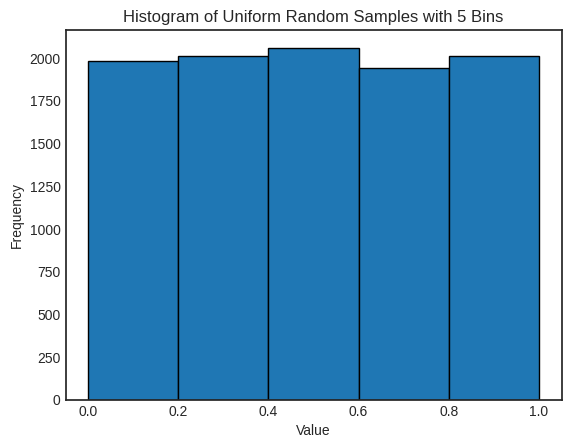

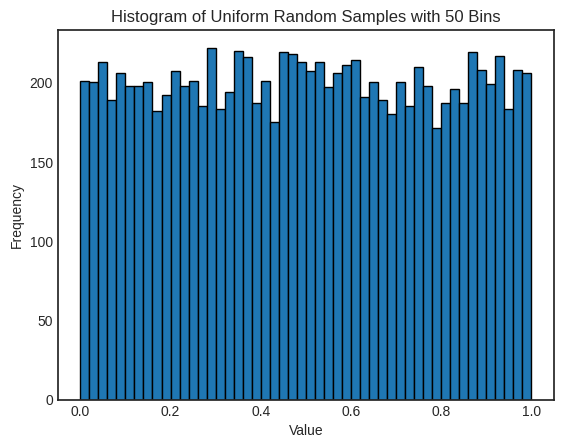

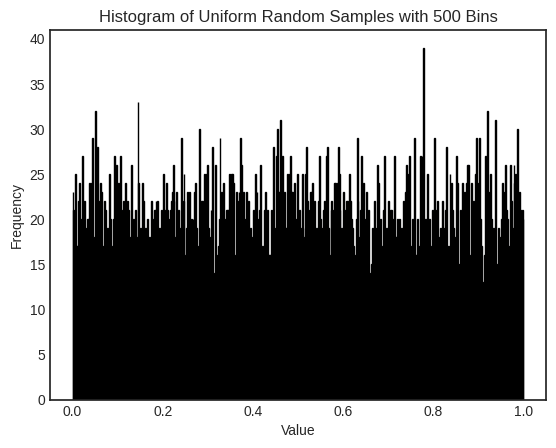

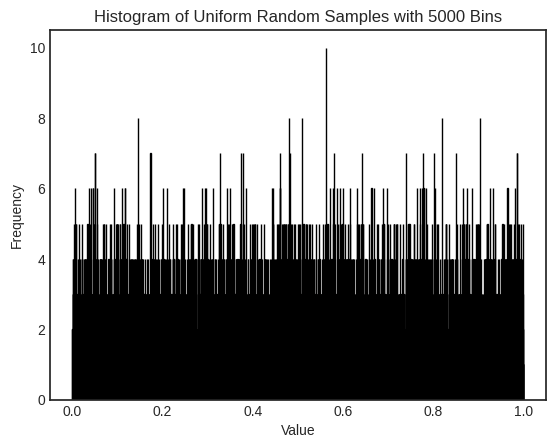

In [ ]:
# Define the bin counts to use
bin_counts = [5, 50, 500, 5000]

# Draw histograms for each bin count
for bins in bin_counts:
    plt.figure() # Create a new figure for each histogram
    plt.hist(norm_data, bins=bins, edgecolor='black')
    plt.title(f'Histogram of Uniform Random Samples with {bins} Bins')
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.show()

**Explain your observations in text box of above step.**

You're referring to the explanation of the histograms with varying bin counts. Here's a summary of the observations:

With 5 bins: You'll see a very coarse representation of the data. Since the data is uniformly distributed, this histogram will likely appear as a few broad, roughly equal-height bars, giving a very general overview without much detail.

With 50 bins: This histogram will provide a much more refined view of the distribution. It should still reflect the uniform nature of the data, but with more granularity, showing the frequency across more intervals.

With 500 bins: As the number of bins increases, the histogram becomes even more detailed. For 10,000 samples across 500 bins, each bin will on average contain 20 data points. You might start to see more fine-grained variations, but it should still largely appear flat, indicating uniformity.

With 5000 bins: At this point, the histogram will appear very noisy and jagged. With 10,000 samples spread across 5,000 bins, many bins will likely have counts of 0, 1, 2, or a few more. This level of binning often highlights the randomness of individual data points rather than the underlying distribution, making the uniform nature harder to discern due to too much detail and sparsity.

**Ploting from a CSV File**

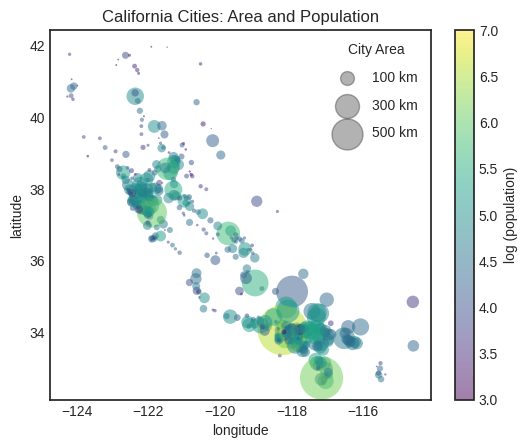

In [ ]:
# Path to file /content/california_cities.csv

import pandas as pd
cities = pd.read_csv('/content/california_cities.csv')

# Extract the data we're interested in
lat, lon = cities['latd'], cities['longd']
population, area = cities['population_total'], cities['area_total_km2']

# Scatter the points, using size and color but no label
plt.scatter(lon, lat, label=None,
            c=np.log10(population), cmap='viridis',
            s=area, linewidth=0, alpha=0.5)
plt.gca().set_aspect('equal')
plt.xlabel('longitude')
plt.ylabel('latitude')
plt.colorbar(label='log (population)')
plt.clim(3, 7)

# Here we create a legend:
# we'll plot empty lists with the desired size and label
for area in [100, 300, 500]:
    plt.scatter([], [], c='k', alpha=0.3, s=area,
                label=str(area) + ' km')
plt.legend(scatterpoints=1, frameon=False, labelspacing=1, title='City Area')

plt.title('California Cities: Area and Population');

Multiple Subplots
Sometimes it is helpful to compare different views of data side by side. Matplotlib has the concept of subplots : groups of smaller axes that can exist together within a single figure.

These subplots might be insets, grids of plots, or other more complicated layouts.

In [ ]:
plt.style.use('seaborn-v0_8-white')
import numpy as np

**plt.axes: Subplots by Hand (Coding)**
The most basic method of creating an axes is to use the plt.axes function. By default this creates a standard axes object that fills the entire figure.

plt.axes also takes an optional argument that is a list of four numbers in the figure coordinate system. These numbers represent [left, bottom, width, height] in the figure coordinate system, which ranges from 0 at the bottom left of the figure to 1 at the top right of the figure.

For example, we might create an inset axes at the top-right corner of another axes by setting the x and y position to 0.65 (that is, starting at 65% of the width and 65% of the height of the figure) and the x and y extents to 0.2 (that is, the size of the axes is 20% of the width and 20% of the height of the figure):

Text(0.5, 1.0, 'Inset Plot')

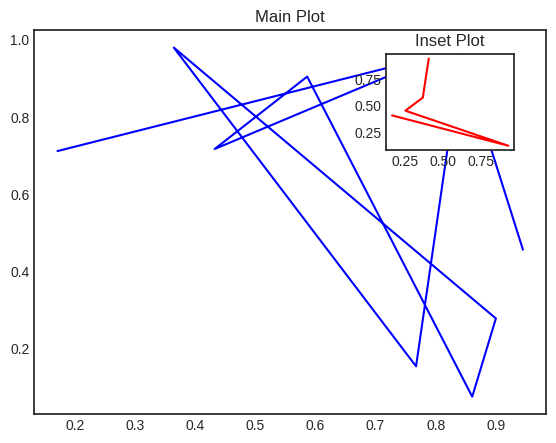

In [ ]:
fig = plt.figure()
ax1 = fig.add_axes([0.1, 0.1, 0.8, 0.8]) # main axes
ax2 = fig.add_axes([0.65, 0.65, 0.2, 0.2]) # inset axes

ax1.plot(np.random.rand(10), np.random.rand(10), color='blue')
ax1.set_title('Main Plot')

ax2.plot(np.random.rand(5), np.random.rand(5), color='red')
ax2.set_title('Inset Plot')

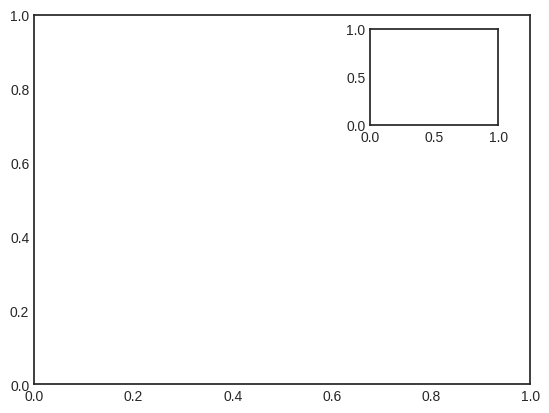

In [ ]:
ax1 = plt.axes()  # standard axes
ax2 = plt.axes([0.650, 0.650, 0.2, 0.2]) #inset axes

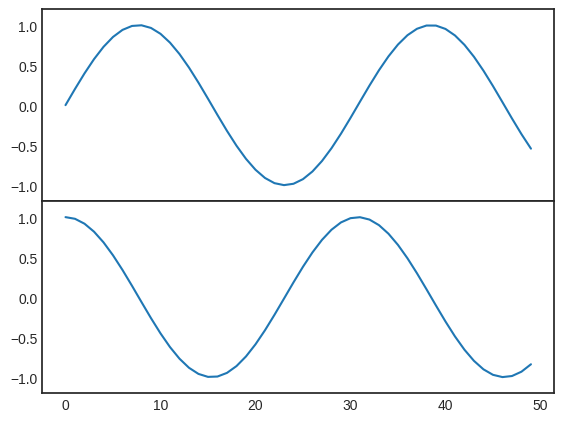

In [ ]:
#creating subplot using fig.add_axes
fig = plt.figure()
ax1 = fig.add_axes([0.1, 0.5, 0.8, 0.4],
                   xticklabels=[], ylim=(-1.2, 1.2))
ax2 = fig.add_axes([0.1, 0.1, 0.8, 0.4],
                   ylim=(-1.2, 1.2))

x = np.linspace(0, 10)
ax1.plot(np.sin(x))
ax2.plot(np.cos(x));


plt.subplot: Simple Grids of Subplots
Aligned columns or rows of subplots are a common-enough need that Matplotlib has several convenience routines that make them easy to create.

The lowest level of these is plt.subplot(), which creates a single subplot within a grid.

As you can see, this command takes three integer arguments—the number of rows, the number of columns, and the index of the plot to be created in this scheme, which runs from the upper left to the bottom right:

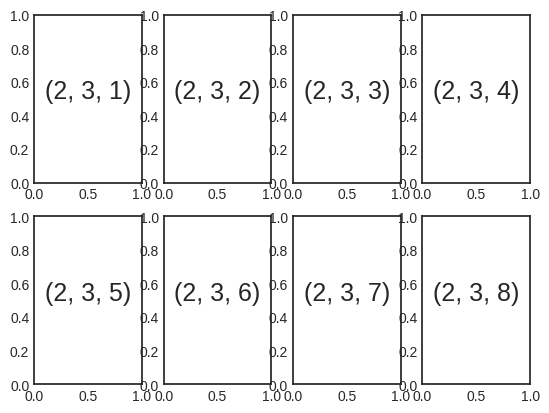

In [ ]:
for i in range(1, 9):
    plt.subplot(2, 4, i)
    plt.text(0.5, 0.5, str((2, 3, i)),
             fontsize=18, ha='center')


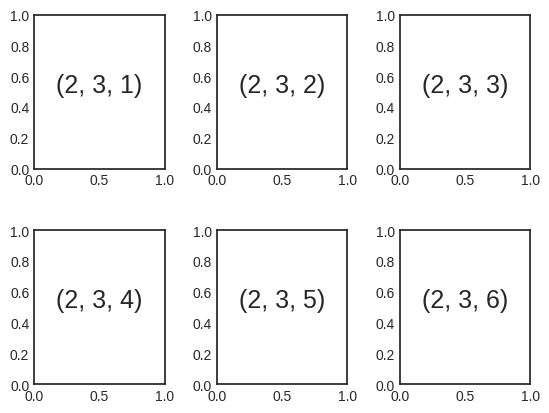

In [ ]:
fig = plt.figure()
fig.subplots_adjust(hspace=0.4, wspace=0.4)
for i in range(1, 7):
    ax = fig.add_subplot(2, 3, i)
    ax.text(0.5, 0.5, str((2, 3, i)),
           fontsize=18, ha='center')

plt.subplots: The Whole Grid in One Go
The approach just described can become quite tedious when creating a large grid of subplots, especially if you'd like to hide the x- and y-axis labels on the inner plots. For this purpose, plt.subplots() is the easier tool to use (note the s at the end of subplots). Rather than creating a single subplot, this function creates a full grid of subplots in a single line, returning them in a NumPy array. The arguments are the number of rows and number of columns, along with optional keywords sharex and sharey, which allow you to specify the relationships between different axes.

Here we'll create a
 grid of subplots, where all axes in the same row share their y-axis scale, and all axes in the same column share their x-axis scale:

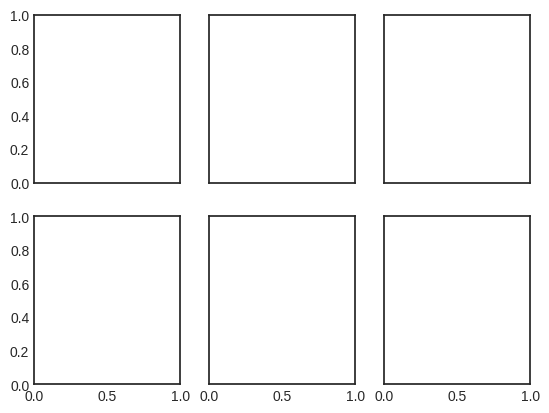

In [ ]:
fig, ax = plt.subplots(2, 3, sharex='col', sharey='row')

Note that by specifying sharex and sharey, we've automatically removed inner labels on the grid to make the plot cleaner.

The resulting grid of axes instances is returned within a NumPy array, allowing for convenient specification of the desired axes using standard array indexing notation:

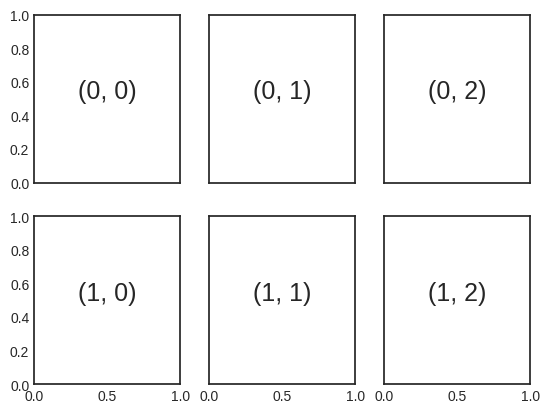

In [ ]:
# axes are in a two-dimensional array, indexed by [row, col]
for i in range(2):
    for j in range(3):
        ax[i, j].text(0.5, 0.5, str((i, j)),
                      fontsize=18, ha='center')
fig

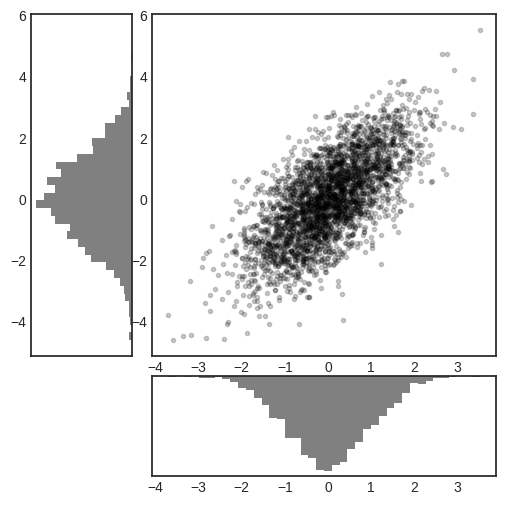

In [ ]:
# An example of Flexible grid arrangement
# Create some normally distributed data
mean = [0, 0]
cov = [[1, 1], [1, 2]]
x, y = np.random.multivariate_normal(mean, cov, 3000).T

# Set up the axes with gridspec
fig = plt.figure(figsize=(6, 6))
grid = plt.GridSpec(4, 4, hspace=0.2, wspace=0.2)
main_ax = fig.add_subplot(grid[:-1, 1:])
y_hist = fig.add_subplot(grid[:-1, 0], xticklabels=[], sharey=main_ax)
x_hist = fig.add_subplot(grid[-1, 1:], yticklabels=[], sharex=main_ax)

# scatter points on the main axes
main_ax.plot(x, y, 'ok', markersize=3, alpha=0.2)

# histogram on the attached axes
x_hist.hist(x, 40, histtype='stepfilled',
            orientation='vertical', color='gray')
x_hist.invert_yaxis()

y_hist.hist(y, 40, histtype='stepfilled',
            orientation='horizontal', color='gray')
y_hist.invert_xaxis()


In [ ]:
import matplotlib as mpl
# An example of Complex Plotting
births = pd.read_csv('/content/births.csv')

quartiles = np.percentile(births['births'], [25, 50, 75])
mu, sig = quartiles[1], 0.74 * (quartiles[2] - quartiles[0])
births = births.query('(births > @mu - 5 * @sig) & (births < @mu + 5 * @sig)')

births['day'] = births['day'].astype(int)

births.index = pd.to_datetime(10000 * births.year +
                              100 * births.month +
                              births.day, format='%Y%m%d')
births_by_date = births.pivot_table('births',
                                    [births.index.month, births.index.day])
births_by_date.index = [pd.Timestamp(2012, month, day)
                        for (month, day) in births_by_date.index]

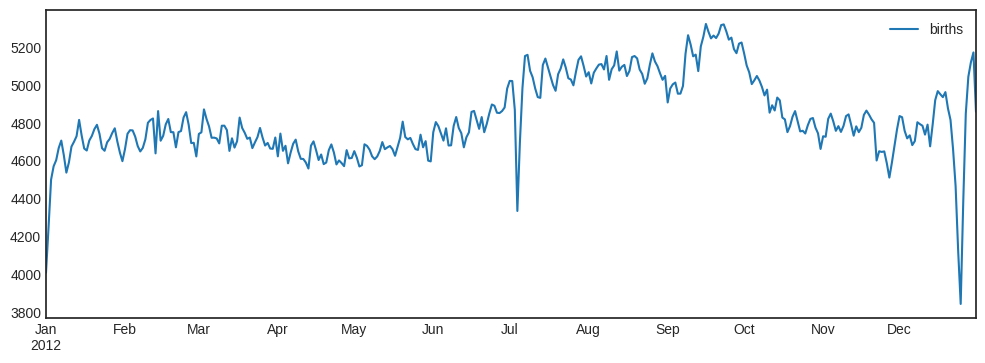

In [ ]:

fig, ax = plt.subplots(figsize=(12, 4))
births_by_date.plot(ax=ax);

**Boxplot**

A Box Plot is also known as Whisker plot is created to display the summary of the set of data values having properties like minimum, first quartile, median, third quartile and maximum.

In the box plot, a box is created from the first quartile to the third quartile, a vertical line is also there which goes through the box at the median. Here x-axis denotes the data to be plotted while the y-axis shows the frequency distribution.

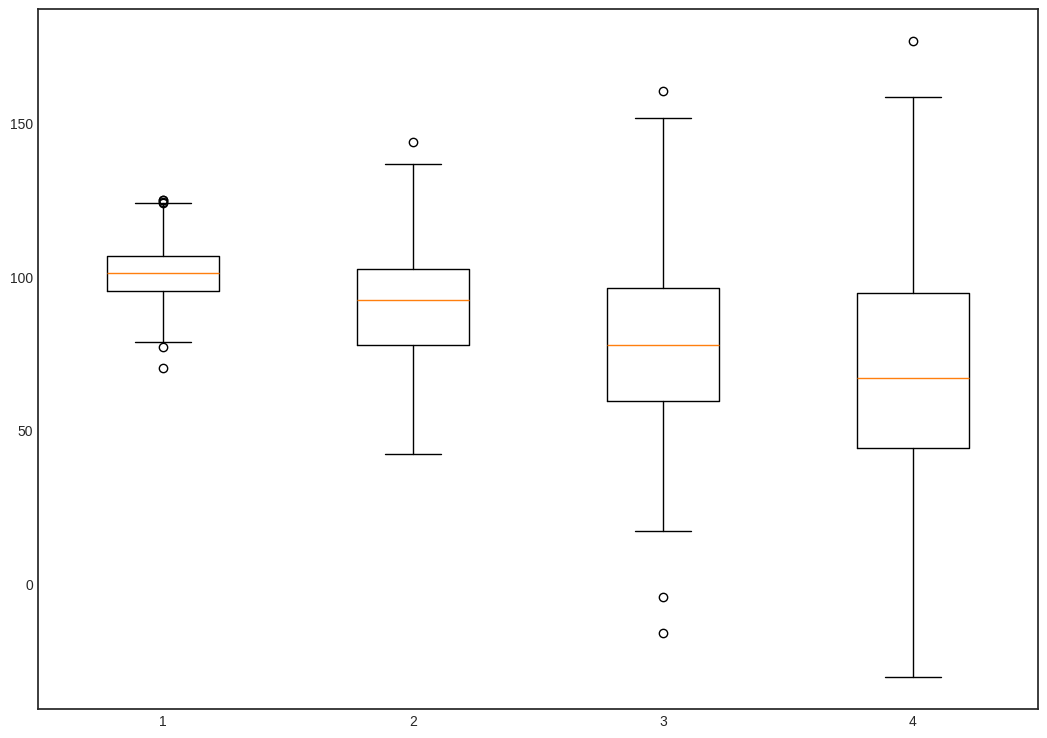

In [ ]:
#Exmple of Box plot for some random data sets
# Import libraries
import matplotlib.pyplot as plt
import numpy as np


# Creating dataset
np.random.seed(10)

data_1 = np.random.normal(100, 10, 200)
data_2 = np.random.normal(90, 20, 200)
data_3 = np.random.normal(80, 30, 200)
data_4 = np.random.normal(70, 40, 200)
data = [data_1, data_2, data_3, data_4]

fig = plt.figure(figsize =(10, 7))

# Creating axes instance
ax = fig.add_axes([0, 0, 1, 1])

# Creating plot
bp = ax.boxplot(data)

# show plot
plt.show()


**Questions:**

**Q1What is boxplot ?**
A Box Plot, also known as a Whisker plot, is a graphical representation designed to display the summary of a set of data values. It highlights several key statistical properties:

Minimum: The smallest data point.
First Quartile (Q1): The 25th percentile, marking the lower end of the box.
Median (Q2): The 50th percentile, represented by a line within the box.
Third Quartile (Q3): The 75th percentile, marking the upper end of the box.
Maximum: The largest data point, often within 1.5 times the interquartile range from the quartiles.
The box itself spans from the first quartile to the third quartile, covering the interquartile range (IQR). Lines (whiskers) extend from the box to the minimum and maximum values, and individual points beyond the whiskers may be plotted as outliers. It provides a quick visual summary of the data's distribution, central tendency, and spread.

**Q2What information do we get from a box plot?**

From a box plot, you can gather several key pieces of information about the distribution of a dataset:

Median (Q2): The line inside the box represents the median, which is the 50th percentile of the data. This indicates the central tendency of the data.
Interquartile Range (IQR): The box itself spans from the first quartile (Q1, 25th percentile) to the third quartile (Q3, 75th percentile). The length of the box represents the IQR, which is a measure of the spread or dispersion of the middle 50% of the data.
First Quartile (Q1): The bottom edge of the box (for a vertical box plot) shows the 25th percentile of the data.
Third Quartile (Q3): The top edge of the box (for a vertical box plot) shows the 75th percentile of the data.
Whiskers: The lines extending from the box (whiskers) typically indicate the range of the data, excluding outliers. They usually extend to the minimum and maximum values within 1.5 times the IQR from the Q1 and Q3, respectively.
Outliers: Individual points plotted beyond the whiskers are considered outliers, suggesting data points that are significantly different from the rest of the dataset.
Symmetry/Skewness: The position of the median within the box and the relative lengths of the whiskers can give an indication of the data's skewness (i.e., whether the data is symmetric or skewed to one side).
Spread/Variability: The overall length of the box and whiskers gives a visual sense of how spread out the data is.

**Q3How is minimum and maximum whisker's marked in a box plot ? **

In a box plot, the minimum and maximum whiskers are typically marked as follows:

Minimum Whisker: This whisker extends from the first quartile (Q1, the bottom of the box) down to the lowest data point that is not considered an outlier. This lowest non-outlier value is usually defined as Q1 - 1.5 * IQR, where IQR is the Interquartile Range (Q3 - Q1). Any data points below this value are marked as individual outliers.

Maximum Whisker: Similarly, this whisker extends from the third quartile (Q3, the top of the box) up to the highest data point that is not considered an outlier. This highest non-outlier value is usually defined as Q3 + 1.5 * IQR. Any data points above this value are marked as individual outliers.

It's important to note that the exact definition of whiskers can sometimes vary slightly depending on the software or statistical package used, but the 1.5 * IQR rule is the most common convention.

**Q4How to we identify that some points in data are outliers by viewing the box plot?**
In a box plot, outliers are typically identified as individual data points that fall outside the range defined by the whiskers. These points are usually plotted as single markers (like dots, crosses, or stars) beyond the upper or lower whiskers.

To be more specific:

If a data point is below the lower whisker, it's considered a low outlier.
If a data point is above the upper whisker, it's considered a high outlier.
The whiskers themselves extend to the most extreme data points within a certain range, commonly 1.5 times the Interquartile Range (IQR) from the first (Q1) and third (Q3) quartiles. Any data point that lies beyond these 1.5 * IQR boundaries is flagged as an outlier.

**Q5Read a data file from your drive and for all numeric columns plot boxplot.**


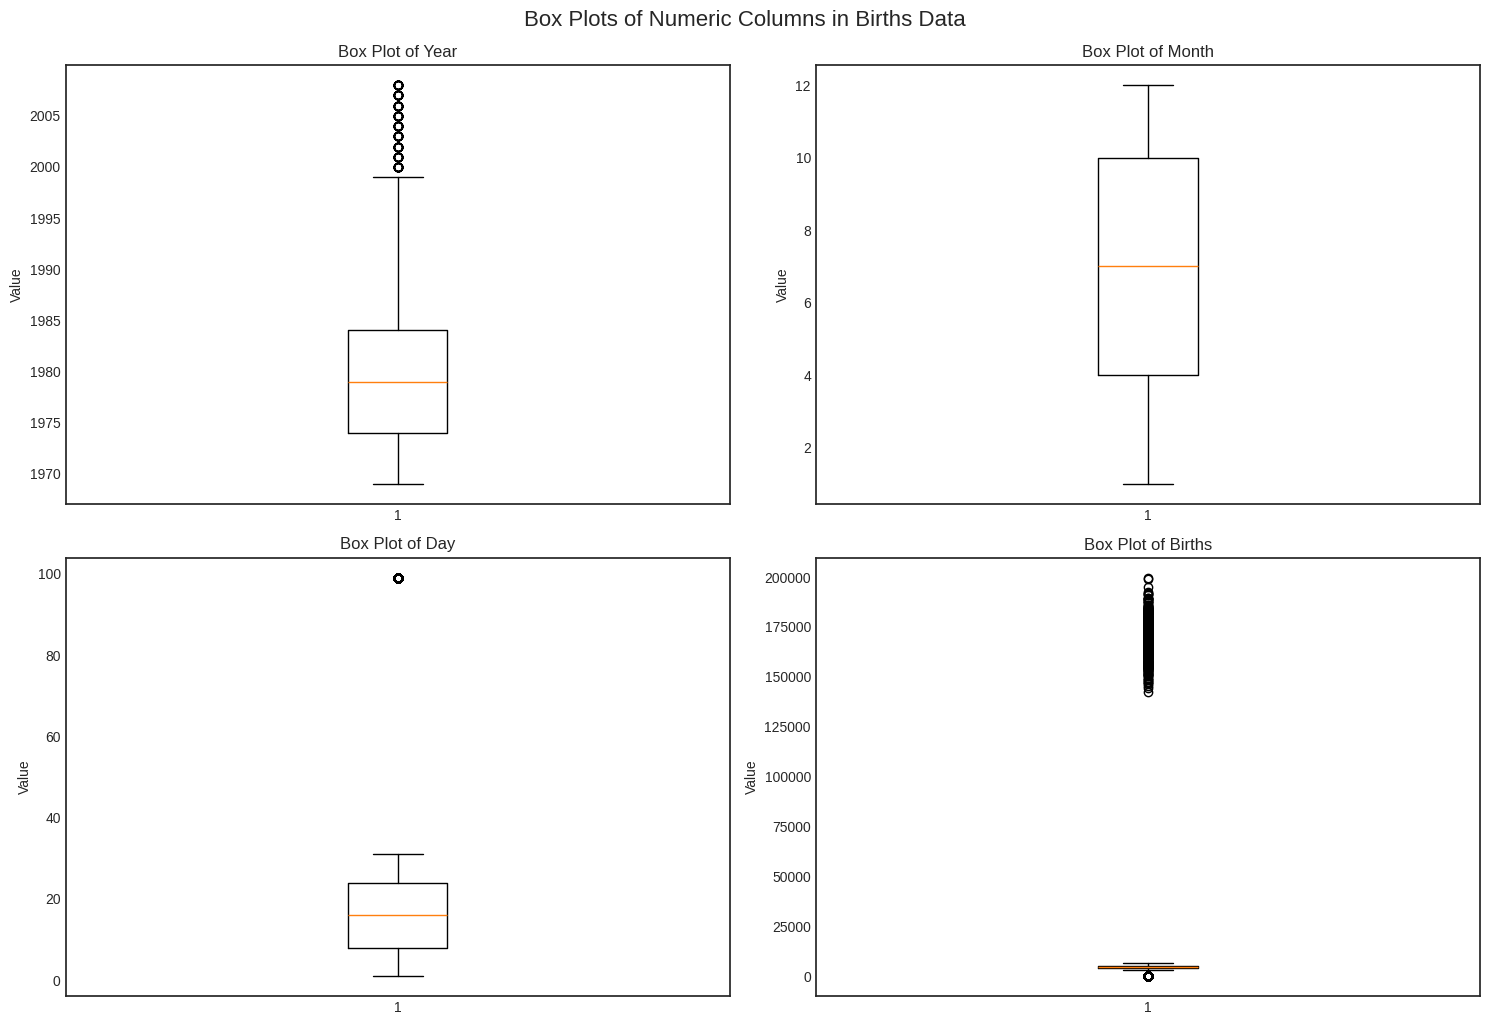

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get the number of numeric columns
num_cols = len(numeric_cols)

# Determine the grid size for subplots. For 4 columns, a 2x2 grid is suitable.
rows = int(np.ceil(num_cols / 2))
cols = 2

fig, axes = plt.subplots(rows, cols, figsize=(15, 10))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    ax.boxplot(births_df[col].dropna()) # Drop NA values for boxplot
    ax.set_title(f'Box Plot of {col.capitalize()}')
    ax.set_ylabel('Value')

# Hide any unused subplots if num_cols is not a perfect multiple of cols
for j in range(num_cols, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Box Plots of Numeric Columns in Births Data', y=1.02, fontsize=16) # Add a suptitle
plt.show()

# Task
Load the data from the '/content/births.csv' file, identify all numeric columns within the DataFrame, and then generate a box plot for each of these numeric columns. All box plots should be displayed in a single figure for easy comparison.

## Load Data File

### Subtask:
Load the data from the specified CSV file ('/content/births.csv' by default, assuming it's available in the environment) into a pandas DataFrame. This step will also handle potential file not found errors.


**Reasoning**:
The subtask requires loading a CSV file into a pandas DataFrame. First, I need to import the pandas library, then attempt to read the specified CSV file into a DataFrame, and handle potential FileNotFoundError. Finally, I will display the first few rows of the DataFrame to verify the load.



In [ ]:
import pandas as pd

try:
    births_df = pd.read_csv('/content/births.csv')
    print("Data loaded successfully. First 5 rows:")
    print(births_df.head())
except FileNotFoundError:
    print("Error: The file '/content/births.csv' was not found. Please ensure the file exists in the specified path.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Data loaded successfully. First 5 rows:
   year  month  day gender  births
0  1969      1  1.0      F    4046
1  1969      1  1.0      M    4440
2  1969      1  2.0      F    4454
3  1969      1  2.0      M    4548
4  1969      1  3.0      F    4548


**Reasoning**:
The subtask is to identify all numeric columns and then generate box plots for each in a single figure. I will first identify numeric columns from the `births_df` DataFrame and then prepare to plot them.



In [ ]:
numeric_cols = births_df.select_dtypes(include=['number']).columns.tolist()
print(f"Numeric columns identified: {numeric_cols}")

Numeric columns identified: ['year', 'month', 'day', 'births']


**Reasoning**:
Now that the numeric columns have been identified, I will create a single figure with subplots and generate a box plot for each numeric column in the `births_df` DataFrame. This will display the distribution of each numeric feature.



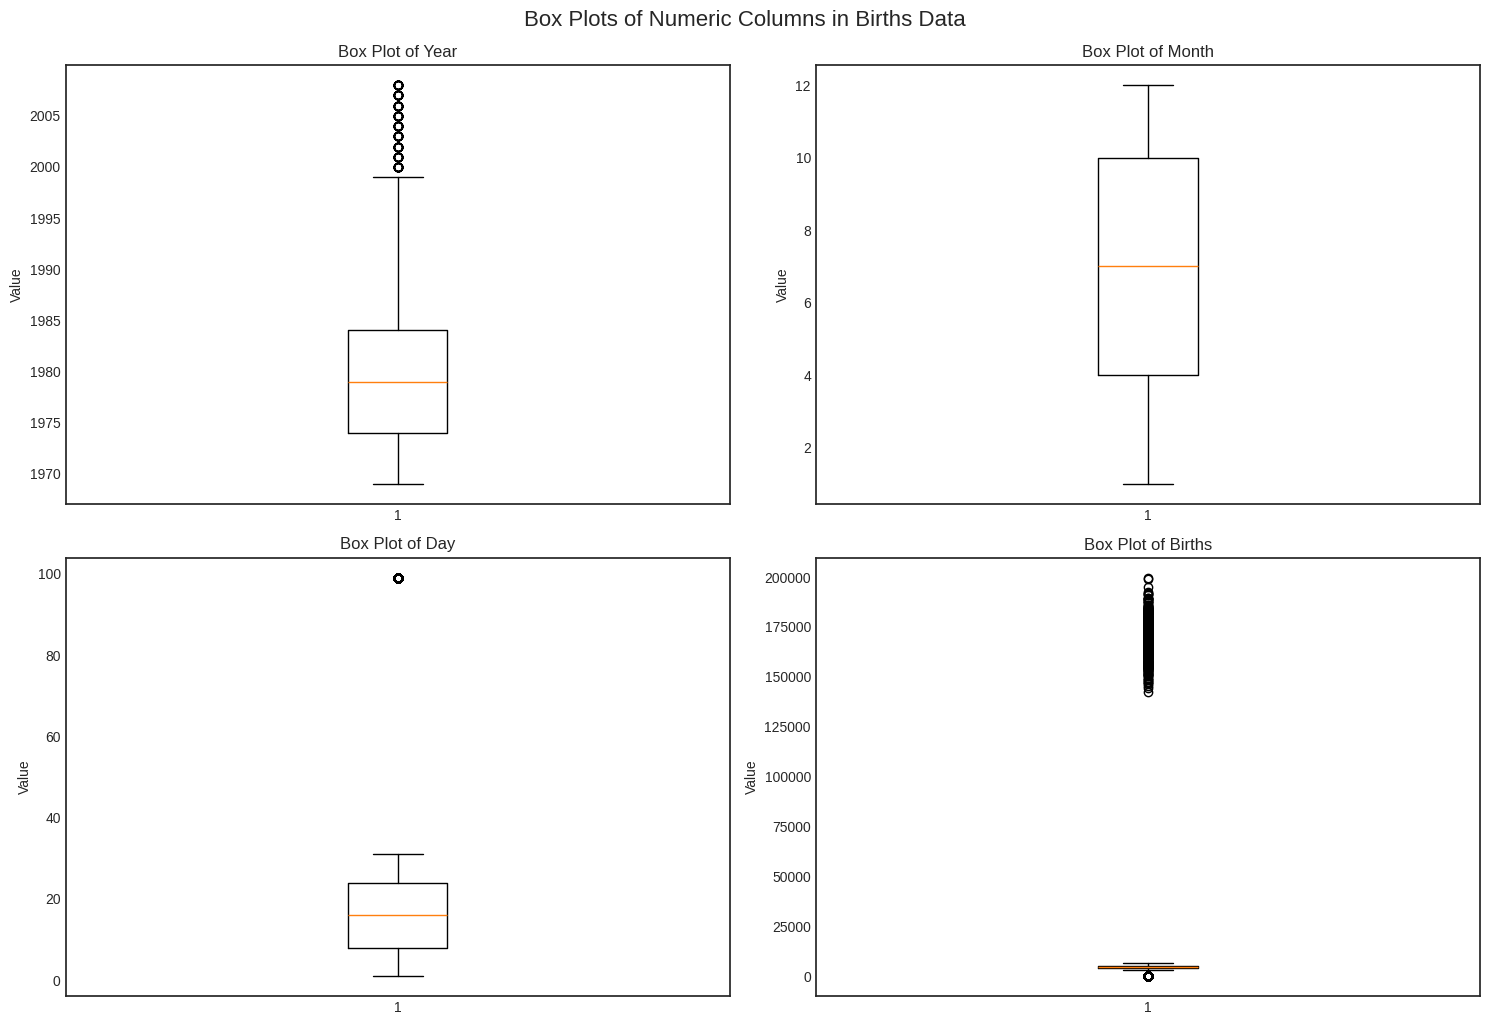

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get the number of numeric columns
num_cols = len(numeric_cols)

# Determine the grid size for subplots. For 4 columns, a 2x2 grid is suitable.
rows = int(np.ceil(num_cols / 2))
cols = 2

fig, axes = plt.subplots(rows, cols, figsize=(15, 10))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    ax.boxplot(births_df[col].dropna()) # Drop NA values for boxplot
    ax.set_title(f'Box Plot of {col.capitalize()}')
    ax.set_ylabel('Value')

# Hide any unused subplots if num_cols is not a perfect multiple of cols
for j in range(num_cols, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Box Plots of Numeric Columns in Births Data', y=1.02, fontsize=16) # Add a suptitle
plt.show()


## Final Task

### Subtask:
Review the generated box plots for each numeric column, summarizing observations regarding data distribution, spread, and any visible outliers.


## Summary:

### Data Analysis Key Findings
*   The `births.csv` dataset was successfully loaded, revealing columns such as `year`, `month`, `day`, `gender`, and `births`.
*   Four numeric columns were identified for analysis: `year`, `month`, `day`, and `births`.
*   Box plots were generated for each of these numeric columns and displayed in a single figure, effectively visualizing their respective data distributions, spread, and potential outliers.

### Insights or Next Steps
*   Further investigation into any identified outliers in columns like `births` or `year` could help determine if they represent data entry errors or significant events.
*   Analyzing the distributions revealed by the box plots for `month` and `day` could inform whether birth counts are uniformly distributed across these periods or exhibit seasonal/daily patterns.
